# Klasifikasi Daun Tanaman Sehat dan Berpenyakit Menggunakan Computer Vision

Notebook ini mengikuti alur proposal: pengambilan data dari *New Plant Diseases Dataset*, preprocessing citra, segmentasi bercak penyakit, ekstraksi fitur warna/tekstur, klasifikasi dengan Random Forest dan XGBoost, lalu evaluasi menggunakan confusion matrix, accuracy, precision, recall, dan F1-score.

Fokus kelas mengikuti proposal:
- Peach: healthy dan bacterial spot
- Pepper bell: healthy dan bacterial spot
- Strawberry: healthy dan leaf scorch

## 1. Persiapan Environment

Bagian ini memuat library yang digunakan selama proses. Jika ada library yang belum tersedia, aktifkan cell instalasi di bawah terlebih dahulu, lalu restart kernel agar import berjalan bersih.

In [1]:
from pathlib import Path
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from plant_classifier.model_store import load_model_bundle, save_model_bundle

warnings.filterwarnings("ignore")

# Seed dibuat tetap agar sampling data, training, dan evaluasi dapat direproduksi.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\apple\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Konfigurasi Dataset

Folder dataset sudah tersedia di dalam direktori proyek. Kode di bawah mencari folder train dan valid, lalu menyaring hanya 6 kelas yang sesuai proposal. Nama folder asli tetap dipakai supaya notebook langsung cocok dengan struktur Kaggle dataset.

In [2]:
# Ubah BASE_DIR jika notebook dijalankan dari lokasi berbeda.
BASE_DIR = Path.cwd()
DATASET_ROOT = BASE_DIR / "archive" / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = BASE_DIR / "archive" / "test" / "test"
MODEL_DIR = BASE_DIR / "models"
FULL_RF_MODEL_PATH = MODEL_DIR / "full_random_forest.pickle"
FULL_XGB_MODEL_PATH = MODEL_DIR / "full_xgboost.pickle"

# Kelas yang digunakan sesuai proposal.
SELECTED_CLASSES = {
    "Peach___Bacterial_spot": "Peach - Bacterial spot",
    "Peach___healthy": "Peach - Healthy",
    "Pepper,_bell___Bacterial_spot": "Pepper bell - Bacterial spot",
    "Pepper,_bell___healthy": "Pepper bell - Healthy",
    "Strawberry___Leaf_scorch": "Strawberry - Leaf scorch",
    "Strawberry___healthy": "Strawberry - Healthy",
}

# Untuk eksperimen cepat, isi angka misalnya 300.
# Jika None, seluruh gambar pada kelas terpilih akan digunakan.
MAX_IMAGES_PER_CLASS_TRAIN = None
MAX_IMAGES_PER_CLASS_VALID = None

print("Dataset root:", DATASET_ROOT)
print("Train tersedia:", TRAIN_DIR.exists())
print("Valid tersedia:", VALID_DIR.exists())
print("Test tersedia:", TEST_DIR.exists())
print("Model pickle Random Forest:", FULL_RF_MODEL_PATH)
print("Model pickle XGBoost:", FULL_XGB_MODEL_PATH)


Dataset root: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\archive\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)
Train tersedia: True
Valid tersedia: True
Test tersedia: True
Model pickle Random Forest: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\models\full_random_forest.pickle
Model pickle XGBoost: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\models\full_xgboost.pickle


In [3]:
def collect_image_paths(split_dir, selected_classes, max_per_class=None):
    """Mengumpulkan path gambar dari folder kelas yang dipilih."""
    rows = []
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}

    for folder_name, readable_label in selected_classes.items():
        class_dir = split_dir / folder_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")

        image_paths = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in valid_ext])
        if max_per_class is not None:
            image_paths = image_paths[:max_per_class]

        for image_path in image_paths:
            rows.append({
                "path": image_path,
                "folder_class": folder_name,
                "label": readable_label,
                "split": split_dir.name,
            })

    return pd.DataFrame(rows)

train_df = collect_image_paths(TRAIN_DIR, SELECTED_CLASSES, MAX_IMAGES_PER_CLASS_TRAIN)
valid_df = collect_image_paths(VALID_DIR, SELECTED_CLASSES, MAX_IMAGES_PER_CLASS_VALID)
all_df = pd.concat([train_df, valid_df], ignore_index=True)

display(all_df.head())
print("Jumlah data train:", len(train_df))
print("Jumlah data valid:", len(valid_df))

,path,folder_class,label,split
0,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach___Bacterial_spot,Peach - Bacterial spot,train
1,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach___Bacterial_spot,Peach - Bacterial spot,train
2,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach___Bacterial_spot,Peach - Bacterial spot,train
3,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach___Bacterial_spot,Peach - Bacterial spot,train
4,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach___Bacterial_spot,Peach - Bacterial spot,train


Jumlah data train: 11065
Jumlah data valid: 2766


,split,label,count
0,train,Peach - Bacterial spot,1838
1,train,Peach - Healthy,1728
2,train,Pepper bell - Bacterial spot,1913
3,train,Pepper bell - Healthy,1988
4,train,Strawberry - Healthy,1824
5,train,Strawberry - Leaf scorch,1774
6,valid,Peach - Bacterial spot,459
7,valid,Peach - Healthy,432
8,valid,Pepper bell - Bacterial spot,478
9,valid,Pepper bell - Healthy,497


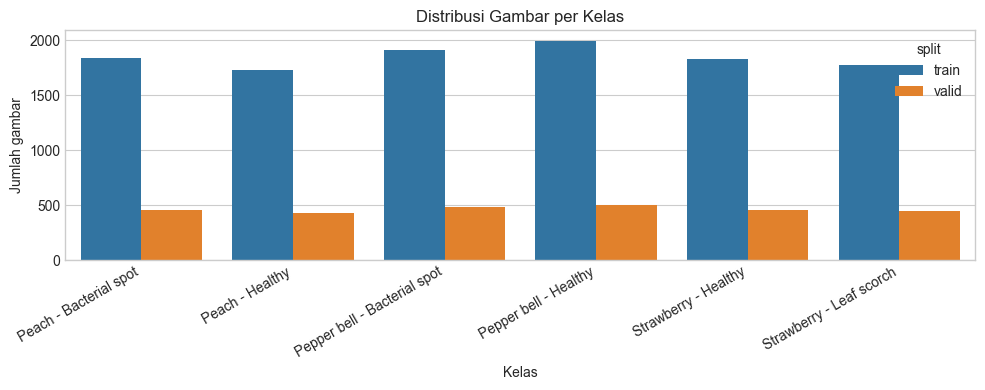

In [4]:
# Distribusi kelas dicek agar terlihat apakah data seimbang atau ada kelas dominan.
summary = (
    all_df.groupby(["split", "label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "label"])
)
display(summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=summary, x="label", y="count", hue="split")
plt.xticks(rotation=30, ha="right")
plt.title("Distribusi Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah gambar")
plt.tight_layout()
plt.show()

## 3. Visualisasi Sampel Gambar

Visualisasi awal membantu memastikan data yang dipakai sudah sesuai kelas target, serta memberi gambaran variasi warna, tekstur, dan bentuk bercak penyakit.

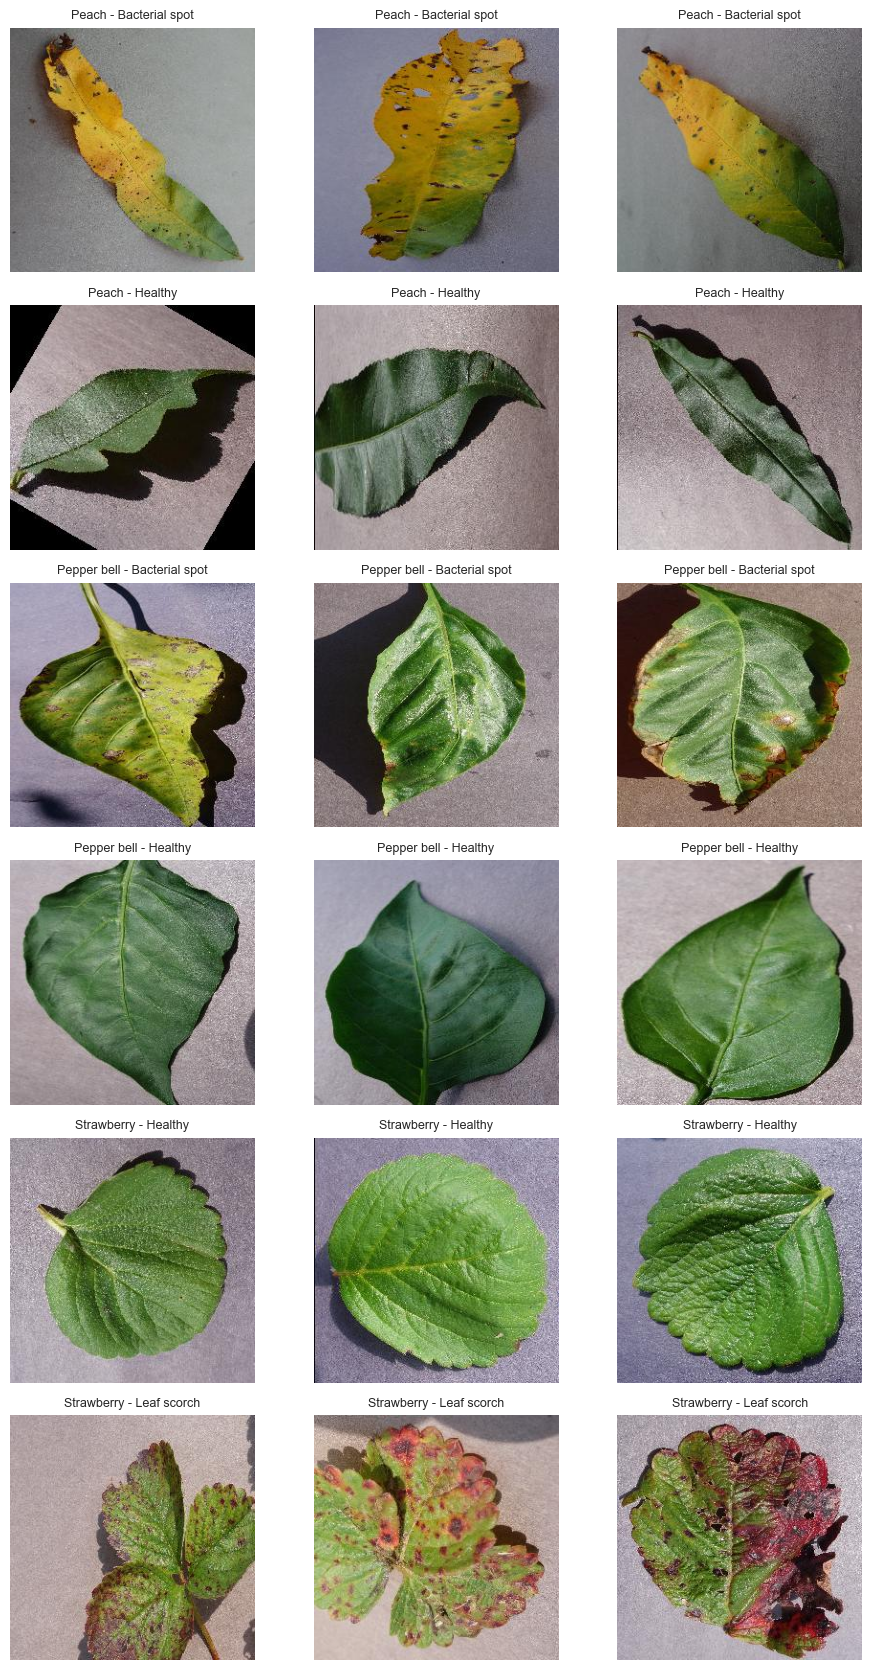

In [5]:
def show_class_samples(df, n_per_class=3):
    """Menampilkan beberapa gambar dari tiap kelas untuk inspeksi awal."""
    labels = sorted(df["label"].unique())
    fig, axes = plt.subplots(len(labels), n_per_class, figsize=(3.2 * n_per_class, 2.8 * len(labels)))

    if len(labels) == 1:
        axes = np.array([axes])

    for row_idx, label in enumerate(labels):
        sample_paths = df[df["label"] == label]["path"].sample(
            min(n_per_class, (df["label"] == label).sum()),
            random_state=RANDOM_STATE
        ).tolist()

        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            if col_idx < len(sample_paths):
                img = Image.open(sample_paths[col_idx]).convert("RGB")
                ax.imshow(img)
                ax.set_title(label, fontsize=9)

    plt.tight_layout()
    plt.show()

show_class_samples(train_df, n_per_class=3)

## 4. Preprocessing Citra

Tahap preprocessing mengikuti proposal:
- Resize agar semua gambar berukuran seragam.
- Noise reduction memakai Gaussian Blur dan Median Filter.
- Color space conversion dari RGB/BGR ke HSV dan LAB untuk kebutuhan fitur warna dan segmentasi.

In [6]:
IMAGE_SIZE = (224, 224)


def read_image(image_path, image_size=IMAGE_SIZE):
    """Membaca gambar dari disk dalam format RGB."""
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Gambar gagal dibaca: {image_path}")
    image_bgr = cv2.resize(image_bgr, image_size, interpolation=cv2.INTER_AREA)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb


def preprocess_image(image_rgb):
    """Melakukan resize lanjutan, pengurangan noise, dan konversi warna."""
    # Gaussian Blur meratakan noise halus tanpa menghilangkan pola besar pada daun.
    gaussian = cv2.GaussianBlur(image_rgb, (5, 5), 0)

    # Median Filter membantu mengurangi noise berbentuk titik yang mungkin muncul di permukaan daun.
    denoised = cv2.medianBlur(gaussian, 3)

    hsv = cv2.cvtColor(denoised, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    gray = cv2.cvtColor(denoised, cv2.COLOR_RGB2GRAY)

    return {
        "rgb": image_rgb,
        "denoised": denoised,
        "hsv": hsv,
        "lab": lab,
        "gray": gray,
    }

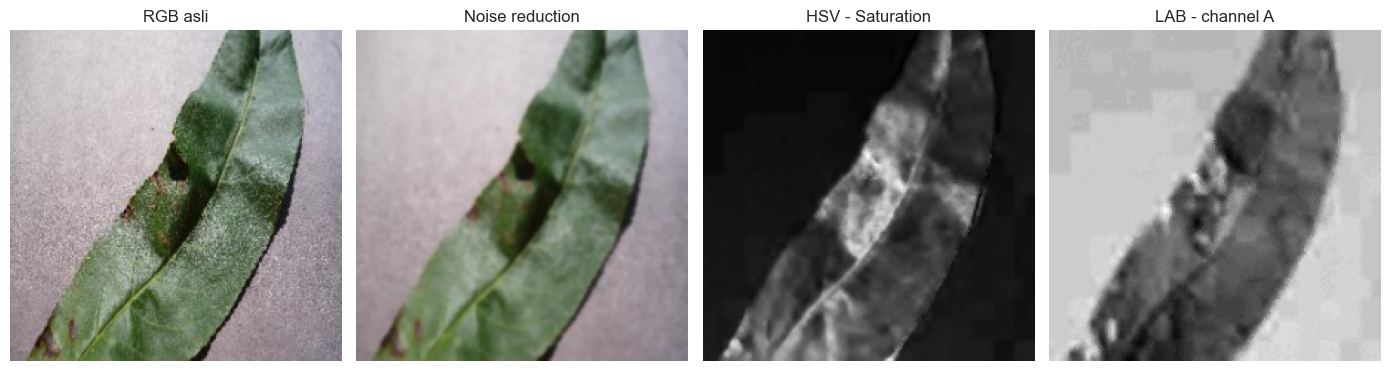

In [7]:
# Contoh hasil preprocessing pada satu gambar.
sample_path = train_df.iloc[0]["path"]
sample_rgb = read_image(sample_path)
sample_processed = preprocess_image(sample_rgb)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(sample_processed["rgb"])
axes[0].set_title("RGB asli")
axes[1].imshow(sample_processed["denoised"])
axes[1].set_title("Noise reduction")
axes[2].imshow(sample_processed["hsv"][:, :, 1], cmap="gray")
axes[2].set_title("HSV - Saturation")
axes[3].imshow(sample_processed["lab"][:, :, 1], cmap="gray")
axes[3].set_title("LAB - channel A")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Segmentasi Bercak Penyakit

Segmentasi dilakukan untuk memperkirakan area daun yang memiliki bercak/kerusakan. Pendekatan yang dipakai:
- Mask daun sederhana dari HSV untuk mengurangi pengaruh background.
- Otsu thresholding pada channel LAB karena LAB memisahkan informasi intensitas dan warna.
- K-Means clustering pada channel A dan B dari LAB untuk mencari kelompok warna yang paling berbeda.
- Morphological opening dan closing untuk membersihkan noise kecil dan merapikan area bercak.

In [8]:
def create_leaf_mask(hsv):
    """Membuat mask area daun menggunakan saturation dan value pada HSV."""
    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    # Daun biasanya memiliki saturasi cukup tinggi dan bukan area sangat gelap.
    mask = ((saturation > 25) & (value > 35)).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


def otsu_spot_mask(lab, leaf_mask):
    """Segmentasi kandidat bercak dengan Otsu thresholding pada LAB."""
    a_channel = lab[:, :, 1]
    b_channel = lab[:, :, 2]

    # Channel A menangkap transisi hijau-merah, sedangkan B menangkap biru-kuning.
    _, otsu_a = cv2.threshold(a_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_b = cv2.threshold(b_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    otsu_mask = cv2.bitwise_or(otsu_a, otsu_b)
    otsu_mask = cv2.bitwise_and(otsu_mask, leaf_mask)
    return otsu_mask


def kmeans_spot_mask(lab, leaf_mask, k=3):
    """Menggunakan K-Means pada channel LAB A-B untuk mencari cluster warna bercak."""
    leaf_pixels = leaf_mask > 0
    if leaf_pixels.sum() < 20:
        return np.zeros(leaf_mask.shape, dtype=np.uint8)

    ab_pixels = lab[:, :, 1:3][leaf_pixels].astype(np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.2)
    _, labels, centers = cv2.kmeans(
        ab_pixels,
        k,
        None,
        criteria,
        3,
        cv2.KMEANS_PP_CENTERS,
    )

    # Bercak penyakit sering bergeser ke warna cokelat/kuning/kemerahan.
    # Skor sederhana ini memilih cluster dengan kombinasi A dan B paling tinggi.
    cluster_scores = centers[:, 0] + centers[:, 1]
    disease_cluster = int(np.argmax(cluster_scores))

    result = np.zeros(leaf_mask.shape, dtype=np.uint8)
    result[leaf_pixels] = (labels.flatten() == disease_cluster).astype(np.uint8) * 255
    return result


def segment_disease_spots(processed):
    """Menggabungkan Otsu, K-Means, dan operasi morfologi untuk mask bercak."""
    hsv = processed["hsv"]
    lab = processed["lab"]

    leaf_mask = create_leaf_mask(hsv)
    otsu_mask = otsu_spot_mask(lab, leaf_mask)
    kmask = kmeans_spot_mask(lab, leaf_mask, k=3)

    combined = cv2.bitwise_or(otsu_mask, kmask)
    combined = cv2.bitwise_and(combined, leaf_mask)

    kernel = np.ones((3, 3), np.uint8)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)

    return leaf_mask, combined

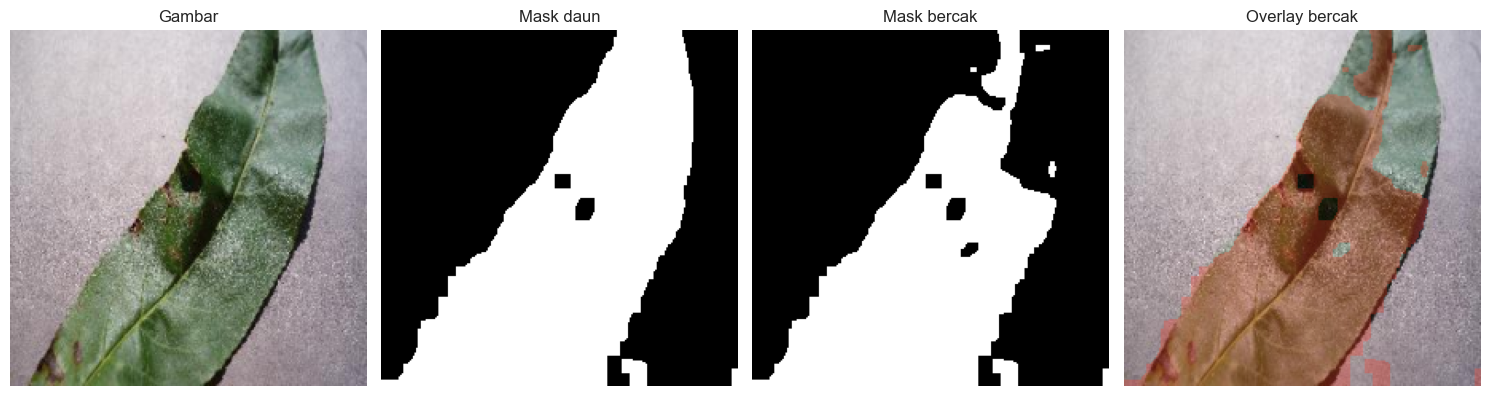

In [9]:
def visualize_segmentation(image_path):
    """Menampilkan citra asli, mask daun, mask bercak, dan overlay segmentasi."""
    image_rgb = read_image(image_path)
    processed = preprocess_image(image_rgb)
    leaf_mask, spot_mask = segment_disease_spots(processed)

    overlay = processed["rgb"].copy()
    overlay[spot_mask > 0] = [255, 60, 40]
    blended = cv2.addWeighted(processed["rgb"], 0.7, overlay, 0.3, 0)

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    axes[0].imshow(processed["rgb"])
    axes[0].set_title("Gambar")
    axes[1].imshow(leaf_mask, cmap="gray")
    axes[1].set_title("Mask daun")
    axes[2].imshow(spot_mask, cmap="gray")
    axes[2].set_title("Mask bercak")
    axes[3].imshow(blended)
    axes[3].set_title("Overlay bercak")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Sampel kelas sakit digunakan agar hasil segmentasi bercak lebih mudah diamati.
disease_sample = train_df[train_df["label"].str.contains("Bacterial|Leaf scorch", regex=True)].iloc[0]["path"]
visualize_segmentation(disease_sample)

## 6. Ekstraksi Fitur

Fitur yang diekstraksi mengikuti proposal:
- Disease Area Ratio: persentase area bercak terhadap area daun.
- Color Moments: mean, standard deviation, dan skewness pada HSV dan LAB.
- GLCM: fitur tekstur seperti contrast, homogeneity, energy, dan correlation.
- LBP: histogram pola tekstur lokal untuk menangkap detail mikro pada permukaan daun.

In [10]:
def safe_skew(values):
    """Menghitung skewness tanpa dependency scipy."""
    values = values.astype(np.float32)
    std = values.std()
    if std < 1e-6:
        return 0.0
    centered = values - values.mean()
    return float(np.mean((centered / std) ** 3))


def color_moments(image, mask, prefix):
    """Mengambil mean, standard deviation, dan skewness dari tiap channel warna."""
    features = {}
    valid = mask > 0
    if valid.sum() == 0:
        valid = np.ones(mask.shape, dtype=bool)

    for channel_idx in range(image.shape[2]):
        values = image[:, :, channel_idx][valid].astype(np.float32)
        features[f"{prefix}_ch{channel_idx}_mean"] = float(values.mean())
        features[f"{prefix}_ch{channel_idx}_std"] = float(values.std())
        features[f"{prefix}_ch{channel_idx}_skew"] = safe_skew(values)

    return features


def glcm_features(gray, mask, levels=16):
    """Menghitung fitur GLCM sederhana pada 4 arah tetangga."""
    quantized = np.clip((gray.astype(np.float32) / 256 * levels).astype(np.int32), 0, levels - 1)
    valid = mask > 0
    offsets = [(0, 1), (1, 0), (1, 1), (1, -1)]
    glcm = np.zeros((levels, levels), dtype=np.float64)

    for dy, dx in offsets:
        y_start = max(0, dy)
        y_end = gray.shape[0] + min(0, dy)
        x_start = max(0, dx)
        x_end = gray.shape[1] + min(0, dx)

        current = quantized[y_start:y_end, x_start:x_end]
        neighbor = quantized[y_start - dy:y_end - dy, x_start - dx:x_end - dx]
        current_mask = valid[y_start:y_end, x_start:x_end]
        neighbor_mask = valid[y_start - dy:y_end - dy, x_start - dx:x_end - dx]
        pair_mask = current_mask & neighbor_mask

        for i, j in zip(current[pair_mask].ravel(), neighbor[pair_mask].ravel()):
            glcm[i, j] += 1

    if glcm.sum() == 0:
        glcm += 1
    glcm /= glcm.sum()

    i_idx, j_idx = np.indices(glcm.shape)
    contrast = np.sum(((i_idx - j_idx) ** 2) * glcm)
    dissimilarity = np.sum(np.abs(i_idx - j_idx) * glcm)
    homogeneity = np.sum(glcm / (1.0 + np.abs(i_idx - j_idx)))
    energy = np.sqrt(np.sum(glcm ** 2))

    mean_i = np.sum(i_idx * glcm)
    mean_j = np.sum(j_idx * glcm)
    std_i = np.sqrt(np.sum(((i_idx - mean_i) ** 2) * glcm))
    std_j = np.sqrt(np.sum(((j_idx - mean_j) ** 2) * glcm))
    correlation = np.sum(((i_idx - mean_i) * (j_idx - mean_j) * glcm) / (std_i * std_j + 1e-8))

    return {
        "glcm_contrast": float(contrast),
        "glcm_dissimilarity": float(dissimilarity),
        "glcm_homogeneity": float(homogeneity),
        "glcm_energy": float(energy),
        "glcm_correlation": float(correlation),
    }


def lbp_histogram(gray, mask):
    """Menghitung histogram LBP 8-neighbor radius 1."""
    center = gray[1:-1, 1:-1]
    neighbors = [
        gray[:-2, :-2], gray[:-2, 1:-1], gray[:-2, 2:],
        gray[1:-1, 2:], gray[2:, 2:], gray[2:, 1:-1],
        gray[2:, :-2], gray[1:-1, :-2],
    ]

    lbp = np.zeros_like(center, dtype=np.uint8)
    for bit, neighbor in enumerate(neighbors):
        lbp |= ((neighbor >= center).astype(np.uint8) << bit)

    valid = mask[1:-1, 1:-1] > 0
    if valid.sum() == 0:
        valid = np.ones_like(center, dtype=bool)

    hist, _ = np.histogram(lbp[valid], bins=16, range=(0, 256), density=True)
    return {f"lbp_bin_{idx:02d}": float(value) for idx, value in enumerate(hist)}


def shape_features(spot_mask, leaf_mask):
    """Mengambil fitur area dan bentuk dari hasil segmentasi bercak."""
    leaf_area = max(int((leaf_mask > 0).sum()), 1)
    spot_area = int((spot_mask > 0).sum())
    contours, _ = cv2.findContours(spot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_areas = [cv2.contourArea(c) for c in contours]

    return {
        "disease_area_ratio": float(spot_area / leaf_area),
        "spot_count": int(len(contours)),
        "largest_spot_ratio": float((max(contour_areas) if contour_areas else 0.0) / leaf_area),
    }


def extract_features(image_path):
    """Pipeline lengkap dari pembacaan gambar sampai fitur numerik."""
    image_rgb = read_image(image_path)
    processed = preprocess_image(image_rgb)
    leaf_mask, spot_mask = segment_disease_spots(processed)

    features = {}
    features.update(shape_features(spot_mask, leaf_mask))
    features.update(color_moments(processed["hsv"], leaf_mask, "hsv"))
    features.update(color_moments(processed["lab"], leaf_mask, "lab"))
    features.update(glcm_features(processed["gray"], leaf_mask, levels=16))
    features.update(lbp_histogram(processed["gray"], leaf_mask))
    return features

In [11]:
def build_feature_table(df, cache_path):
    """Membuat tabel fitur dan menyimpan cache agar eksperimen ulang lebih cepat."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        print(f"Membaca cache fitur: {cache_path}")
        cached = pd.read_csv(cache_path)
        cached["path"] = cached["path"].astype(str)
        return cached

    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Ekstraksi fitur"):
        feature_row = extract_features(row["path"])
        feature_row["path"] = str(row["path"])
        feature_row["label"] = row["label"]
        feature_row["folder_class"] = row["folder_class"]
        feature_row["split"] = row["split"]
        rows.append(feature_row)

    feature_df = pd.DataFrame(rows)
    feature_df.to_csv(cache_path, index=False)
    print(f"Cache fitur disimpan: {cache_path}")
    return feature_df

train_features = build_feature_table(train_df, BASE_DIR / "train_handcrafted_features.csv")
valid_features = build_feature_table(valid_df, BASE_DIR / "valid_handcrafted_features.csv")

display(train_features.head())
print("Jumlah fitur:", train_features.drop(columns=["path", "label", "folder_class", "split"]).shape[1])

Membaca cache fitur: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\train_handcrafted_features.csv
Membaca cache fitur: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\valid_handcrafted_features.csv


,disease_area_ratio,spot_count,largest_spot_ratio,hsv_ch0_mean,hsv_ch0_std,hsv_ch0_skew,hsv_ch1_mean,hsv_ch1_std,hsv_ch1_skew,hsv_ch2_mean,...,lbp_bin_10,lbp_bin_11,lbp_bin_12,lbp_bin_13,lbp_bin_14,lbp_bin_15,path,label,folder_class,split
0,0.837935,6,0.819850,53.513714,23.905870,3.005603,67.010803,36.451344,0.996226,117.699265,...,0.000158,0.000715,0.009830,0.000286,0.008263,0.012290,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,train
1,0.989828,1,0.990750,98.963921,68.878479,0.128833,68.101227,43.159405,0.907035,107.432205,...,0.000234,0.001398,0.006366,0.000286,0.005124,0.015722,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,train
2,0.988622,1,0.971095,32.409206,8.818264,6.138211,136.300095,48.180965,0.251223,120.866623,...,0.000157,0.000752,0.010831,0.000335,0.009125,0.009716,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,train
3,0.999163,1,0.979085,45.243973,53.452290,1.981675,148.586197,72.339096,-0.707851,136.703323,...,0.000201,0.001099,0.005777,0.000399,0.006956,0.014684,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,train
4,0.993657,2,0.924012,50.256706,44.407917,2.189999,139.074066,61.267204,-0.501261,99.720322,...,0.000206,0.001015,0.004813,0.000313,0.006691,0.018055,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,train


Jumlah fitur: 42


## 7. Training Model Machine Learning

Vektor fitur yang sudah diperoleh digunakan untuk melatih model klasifikasi. Random Forest dipakai sebagai baseline kuat untuk fitur tabular. XGBoost disiapkan sebagai model lanjutan; jika package belum tersedia, bagian XGBoost akan dilewati tanpa menghentikan notebook.

In [12]:
feature_columns = [
    col for col in train_features.columns
    if col not in ["path", "label", "folder_class", "split"]
]

X_train = train_features[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
X_valid = valid_features[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
y_train_label = train_features["label"]
y_valid_label = valid_features["label"]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_label)
y_valid = label_encoder.transform(y_valid_label)
class_names = label_encoder.classes_

# Class weight membantu jika distribusi kelas tidak sepenuhnya seimbang.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight_dict = {idx: weight for idx, weight in enumerate(class_weights)}

print("Daftar kelas:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

Daftar kelas:
0: Peach - Bacterial spot
1: Peach - Healthy
2: Pepper bell - Bacterial spot
3: Pepper bell - Healthy
4: Strawberry - Healthy
5: Strawberry - Leaf scorch


In [13]:
if FULL_RF_MODEL_PATH.exists():
    rf_bundle = load_model_bundle(FULL_RF_MODEL_PATH)
    rf_model = rf_bundle.model
    feature_columns = rf_bundle.feature_columns
    X_train = train_features[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_valid = valid_features[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    rf_pred = rf_model.predict(X_valid)
    print(f"Random Forest dimuat dari pickle: {FULL_RF_MODEL_PATH}")
else:
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_valid)

    MODEL_DIR.mkdir(exist_ok=True)
    save_model_bundle(
        FULL_RF_MODEL_PATH,
        variant="full",
        model_name="Full Random Forest",
        model=rf_model,
        label_encoder=label_encoder,
        feature_columns=feature_columns,
        metrics={"accuracy": float(accuracy_score(y_valid, rf_pred))},
        metadata={"random_state": RANDOM_STATE},
    )
    print(f"Random Forest selesai dilatih dan disimpan ke pickle: {FULL_RF_MODEL_PATH}")


Random Forest dimuat dari pickle: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\models\full_random_forest.pickle


In [14]:
# XGBoost bersifat opsional. Jika belum terpasang, jalankan cell instalasi di awal notebook.
xgb_model = None
xgb_pred = None

if FULL_XGB_MODEL_PATH.exists():
    xgb_bundle = load_model_bundle(FULL_XGB_MODEL_PATH)
    xgb_model = xgb_bundle.model
    xgb_pred = xgb_model.predict(X_valid)
    print(f"XGBoost dimuat dari pickle: {FULL_XGB_MODEL_PATH}")
else:
    try:
        from xgboost import XGBClassifier

        xgb_model = XGBClassifier(
            n_estimators=350,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        xgb_model.fit(X_train, y_train)
        xgb_pred = xgb_model.predict(X_valid)

        MODEL_DIR.mkdir(exist_ok=True)
        save_model_bundle(
            FULL_XGB_MODEL_PATH,
            variant="full",
            model_name="Full XGBoost",
            model=xgb_model,
            label_encoder=label_encoder,
            feature_columns=feature_columns,
            metrics={"accuracy": float(accuracy_score(y_valid, xgb_pred))},
            metadata={"random_state": RANDOM_STATE},
        )
        print(f"XGBoost selesai dilatih dan disimpan ke pickle: {FULL_XGB_MODEL_PATH}")
    except Exception as exc:
        print("XGBoost dilewati:", exc)


XGBoost dimuat dari pickle: c:\Users\apple\Downloads\Sean\Semester 4\Computer Vision\Project\models\full_xgboost.pickle


## 8. Evaluasi Model

Evaluasi menggunakan metrik yang disebutkan pada proposal: confusion matrix, accuracy, precision, recall, dan F1-score. Metrik macro average memperlakukan semua kelas setara, sedangkan weighted average mempertimbangkan jumlah data per kelas.

In [15]:
def evaluate_model(model_name, y_true, y_pred):
    """Menampilkan metrik evaluasi lengkap untuk satu model."""
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    metrics = pd.DataFrame([
        {
            "model": model_name,
            "accuracy": accuracy,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "f1_weighted": f1_weighted,
        }
    ])

    print(f"=== {model_name} ===")
    display(metrics)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return metrics

all_metrics = [evaluate_model("Random Forest", y_valid, rf_pred)]
if xgb_pred is not None:
    all_metrics.append(evaluate_model("XGBoost", y_valid, xgb_pred))

metrics_df = pd.concat(all_metrics, ignore_index=True)
display(metrics_df)

=== Random Forest ===


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Random Forest,0.973247,0.974238,0.973888,0.973786,0.973631,0.973247,0.97316


                              precision    recall  f1-score   support

      Peach - Bacterial spot       1.00      0.93      0.96       459
             Peach - Healthy       0.98      1.00      0.99       432
Pepper bell - Bacterial spot       0.95      0.98      0.97       478
       Pepper bell - Healthy       0.96      0.95      0.95       497
        Strawberry - Healthy       0.97      0.99      0.98       456
    Strawberry - Leaf scorch       0.99      0.99      0.99       444

                    accuracy                           0.97      2766
                   macro avg       0.97      0.97      0.97      2766
                weighted avg       0.97      0.97      0.97      2766

=== XGBoost ===


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,XGBoost,0.985539,0.985995,0.985752,0.9858,0.985662,0.985539,0.985526


                              precision    recall  f1-score   support

      Peach - Bacterial spot       0.99      0.96      0.98       459
             Peach - Healthy       0.99      1.00      0.99       432
Pepper bell - Bacterial spot       0.97      0.99      0.98       478
       Pepper bell - Healthy       0.98      0.98      0.98       497
        Strawberry - Healthy       0.99      1.00      0.99       456
    Strawberry - Leaf scorch       1.00      0.99      1.00       444

                    accuracy                           0.99      2766
                   macro avg       0.99      0.99      0.99      2766
                weighted avg       0.99      0.99      0.99      2766



,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Random Forest,0.973247,0.974238,0.973888,0.973786,0.973631,0.973247,0.973160
1,XGBoost,0.985539,0.985995,0.985752,0.985800,0.985662,0.985539,0.985526


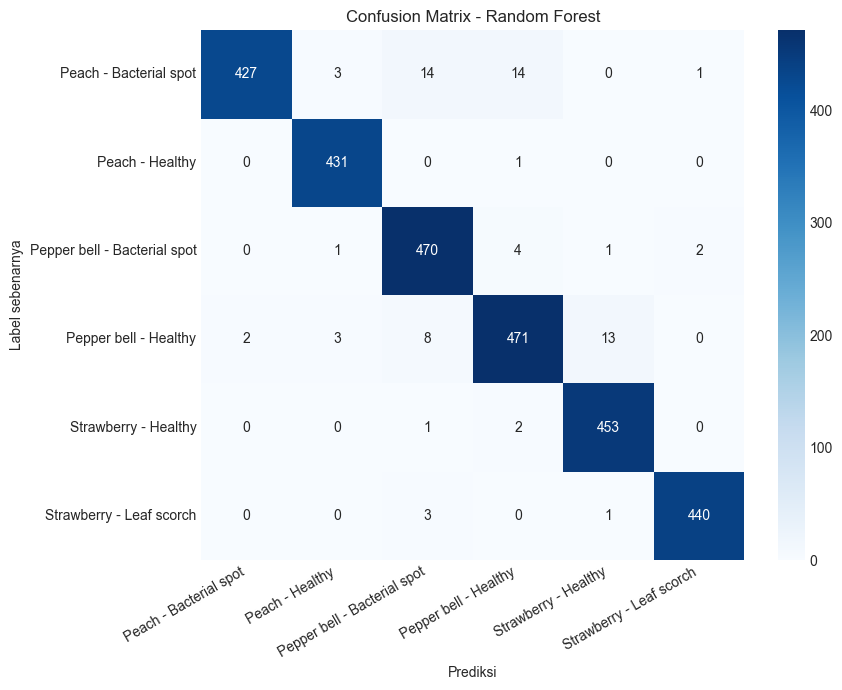

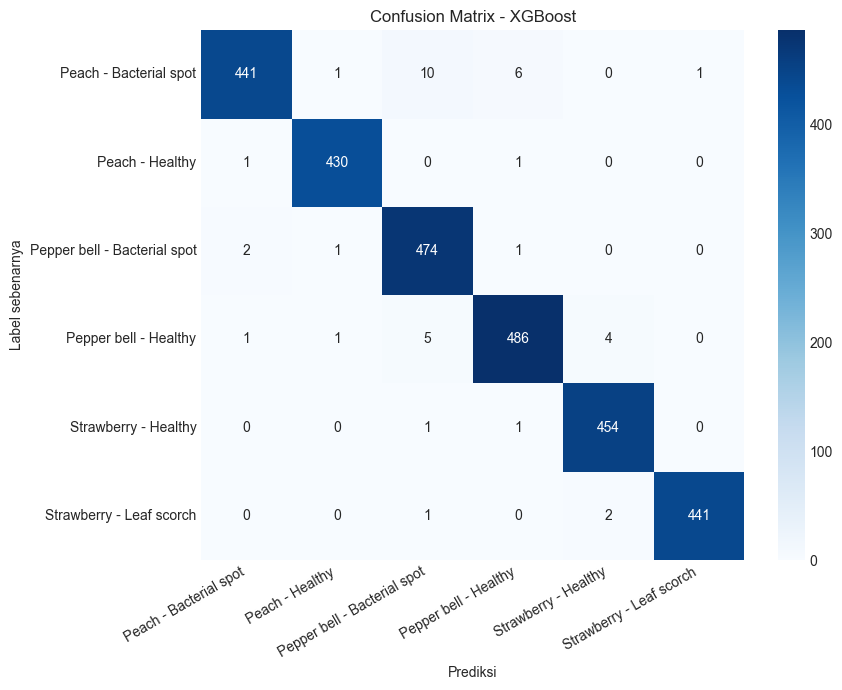

In [16]:
def plot_confusion_matrix(y_true, y_pred, title):
    """Menampilkan confusion matrix dalam bentuk heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Prediksi")
    plt.ylabel("Label sebenarnya")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_valid, rf_pred, "Confusion Matrix - Random Forest")
if xgb_pred is not None:
    plot_confusion_matrix(y_valid, xgb_pred, "Confusion Matrix - XGBoost")

,feature,importance
15,lab_ch1_mean,0.086458
6,hsv_ch1_mean,0.059790
28,lbp_bin_02,0.051243
19,lab_ch2_std,0.051151
32,lbp_bin_06,0.050290
3,hsv_ch0_mean,0.048161
18,lab_ch2_mean,0.044936
30,lbp_bin_04,0.039511
4,hsv_ch0_std,0.038734
21,glcm_contrast,0.037990


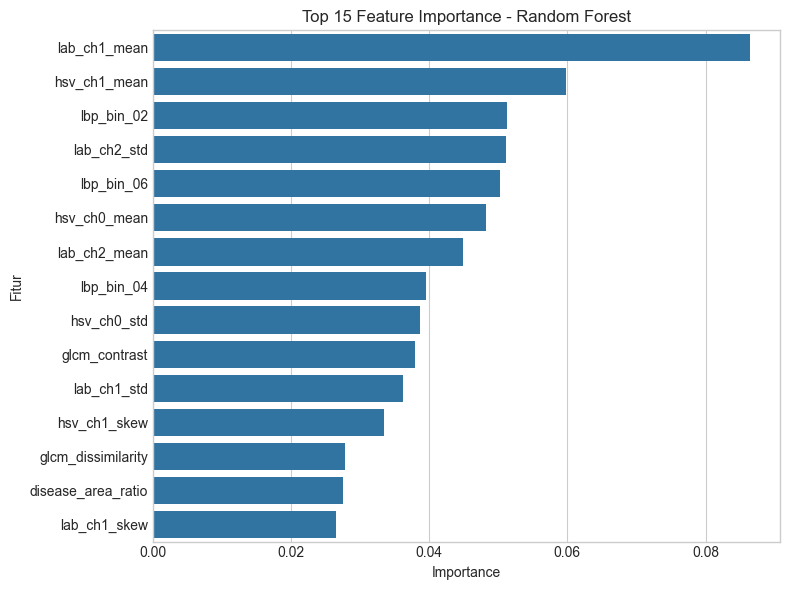

,feature,importance
6,hsv_ch1_mean,0.110977
30,lbp_bin_04,0.098332
21,glcm_contrast,0.059324
32,lbp_bin_06,0.058154
15,lab_ch1_mean,0.054076
28,lbp_bin_02,0.049158
39,lbp_bin_13,0.035587
19,lab_ch2_std,0.033938
18,lab_ch2_mean,0.033607
3,hsv_ch0_mean,0.027763


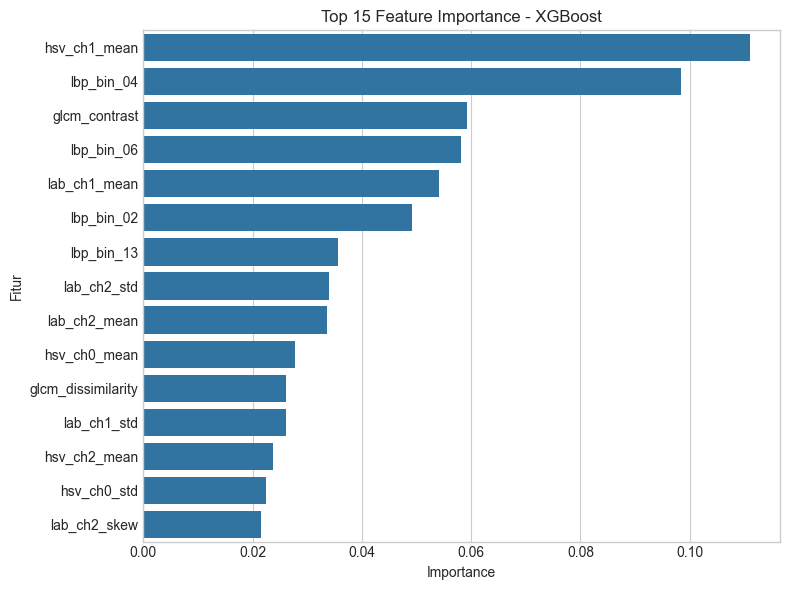

In [17]:
importance_rf_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_rf_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_rf_df.head(15), y="feature", x="importance")
plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


importance_xgb_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_xgb_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_xgb_df.head(15), y="feature", x="importance")
plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

## 9. Analisis Kesalahan Prediksi

Bagian ini menampilkan contoh gambar yang salah diklasifikasikan. Tujuannya untuk melihat apakah kesalahan muncul karena kemiripan warna bercak, variasi pencahayaan, mask segmentasi yang kurang bersih, atau tekstur daun yang mirip antar kelas.

In [18]:
def build_prediction_table(model_name, y_pred):
    """Membuat tabel perbandingan label aktual dan prediksi."""
    table = valid_features[["path", "label", "folder_class"]].copy()
    table["model"] = model_name
    table["actual"] = label_encoder.inverse_transform(y_valid)
    table["predicted"] = label_encoder.inverse_transform(y_pred)
    table["is_correct"] = table["actual"] == table["predicted"]
    return table

rf_predictions = build_prediction_table("Random Forest", rf_pred)
display(rf_predictions.head())
print("Jumlah salah prediksi Random Forest:", (~rf_predictions["is_correct"]).sum())

,path,label,folder_class,model,actual,predicted,is_correct
0,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,Random Forest,Peach - Bacterial spot,Peach - Bacterial spot,True
1,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,Random Forest,Peach - Bacterial spot,Pepper bell - Bacterial spot,False
2,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,Random Forest,Peach - Bacterial spot,Peach - Bacterial spot,True
3,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,Random Forest,Peach - Bacterial spot,Peach - Bacterial spot,True
4,c:\Users\apple\Downloads\Sean\Semester 4\Compu...,Peach - Bacterial spot,Peach___Bacterial_spot,Random Forest,Peach - Bacterial spot,Peach - Bacterial spot,True


Jumlah salah prediksi Random Forest: 74


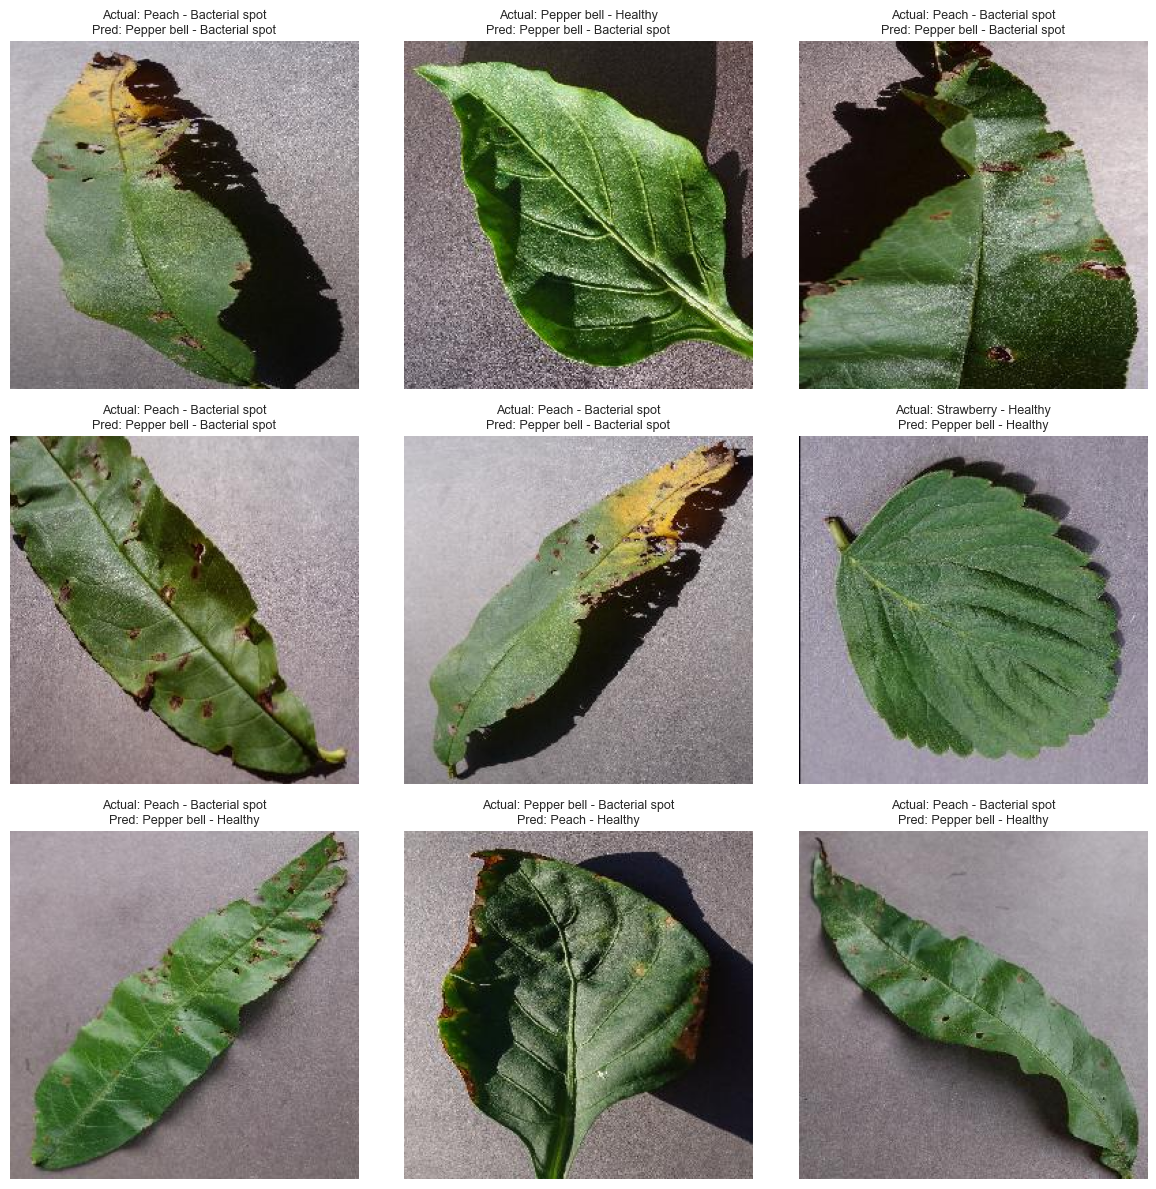

In [19]:
def show_misclassified(prediction_table, max_images=9):
    """Menampilkan sampel salah prediksi dari tabel hasil model."""
    mistakes = prediction_table[~prediction_table["is_correct"]].copy()
    if mistakes.empty:
        print("Tidak ada salah prediksi pada data validasi.")
        return

    sample = mistakes.sample(min(max_images, len(mistakes)), random_state=RANDOM_STATE)
    cols = 3
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Actual: {row['actual']}\nPred: {row['predicted']}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified(rf_predictions, max_images=9)

## 10. Pemeriksaan Folder Test Tambahan

Folder test tambahan dari archive tidak selalu berisi kelas yang sama dengan ruang lingkup proposal. Karena model hanya dilatih untuk Peach, Pepper bell, dan Strawberry, prediksi test hanya dijalankan untuk nama file yang masih berada dalam 3 tanaman target tersebut. Gambar dari tanaman lain dilewati agar hasil tidak disalahartikan.

In [20]:
def collect_test_images(test_dir):
    """Mengambil seluruh gambar dari folder test tambahan."""
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}
    if not test_dir.exists():
        return []
    return sorted([p for p in test_dir.iterdir() if p.suffix.lower() in valid_ext])

# Model terbaik dipilih berdasarkan F1 weighted pada data validasi.
best_model_name = metrics_df.sort_values("f1_weighted", ascending=False).iloc[0]["model"]
best_model = rf_model if best_model_name == "Random Forest" else xgb_model

print("Model untuk prediksi test:", best_model_name)

all_test_paths = collect_test_images(TEST_DIR)
target_keywords = ("peach", "pepper", "strawberry")
test_paths = [
    p for p in all_test_paths
    if any(keyword in p.stem.lower() for keyword in target_keywords)
]
skipped_test_paths = [p for p in all_test_paths if p not in test_paths]

print("Jumlah gambar test tambahan:", len(all_test_paths))
print("Gambar test yang sesuai 3 tanaman target:", len(test_paths))
print("Gambar test di luar ruang lingkup proposal:", len(skipped_test_paths))

if skipped_test_paths:
    print("Contoh file yang dilewati:", [p.name for p in skipped_test_paths[:5]])

if test_paths:
    test_rows = []
    for image_path in tqdm(test_paths, desc="Prediksi test"):
        features = extract_features(image_path)
        X_one = pd.DataFrame([features])[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
        pred = best_model.predict(X_one)[0]
        test_rows.append({
            "path": str(image_path),
            "predicted_label": label_encoder.inverse_transform([pred])[0],
        })

    test_prediction_df = pd.DataFrame(test_rows)
    display(test_prediction_df)
    test_prediction_df.to_csv(BASE_DIR / "test_predictions.csv", index=False)
else:
    test_prediction_df = pd.DataFrame(columns=["path", "predicted_label"])
    print("Tidak ada gambar test tambahan yang sesuai dengan 3 tanaman target proposal.")

Model untuk prediksi test: XGBoost
Jumlah gambar test tambahan: 33
Gambar test yang sesuai 3 tanaman target: 0
Gambar test di luar ruang lingkup proposal: 33
Contoh file yang dilewati: ['AppleCedarRust1.JPG', 'AppleCedarRust2.JPG', 'AppleCedarRust3.JPG', 'AppleCedarRust4.JPG', 'AppleScab1.JPG']
Tidak ada gambar test tambahan yang sesuai dengan 3 tanaman target proposal.


In [21]:
if not test_prediction_df.empty:
    preview = test_prediction_df.sample(min(9, len(test_prediction_df)), random_state=RANDOM_STATE)
    cols = 3
    rows = int(np.ceil(len(preview) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, preview.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["predicted_label"], fontsize=9)
        ax.axis("off")

    for ax in axes[len(preview):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 11. Ringkasan Proses

Alur kerja yang dijalankan:
1. Dataset disaring menjadi 6 kelas sesuai proposal.
2. Gambar diproses dengan resize, Gaussian Blur, Median Filter, dan konversi warna ke HSV/LAB.
3. Area bercak penyakit diperkirakan memakai Otsu thresholding, K-Means clustering, dan morphological operations.
4. Fitur numerik diekstraksi dari area daun dan bercak, termasuk disease area ratio, color moments, GLCM, dan LBP.
5. Model Random Forest dan XGBoost dibandingkan menggunakan confusion matrix, accuracy, precision, recall, dan F1-score.
6. Salah prediksi dianalisis melalui tabel dan visualisasi gambar agar sumber error lebih mudah diamati.

Interpretasi akhir dapat difokuskan pada metrik F1-score dan recall, karena kasus daun sakit yang terlewat dapat berdampak pada penyebaran penyakit ke tanaman lain.